In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

FIG_DIR = "experiment7_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

TRAIN_SAMPLES = 10000
TEST_SAMPLES = 2000
BATCH_SIZE = 128
EPOCHS = 20
LATENT_DIM = 16


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Load MNIST.

(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train = x_train_full[:TRAIN_SAMPLES].astype("float32") / 255.0
x_test = x_test_full[:TEST_SAMPLES].astype("float32") / 255.0

y_train = y_train_full[:TRAIN_SAMPLES]
y_test = y_test_full[:TEST_SAMPLES]

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (10000, 28, 28, 1)
Test images: (2000, 28, 28, 1)
Pixel range: 0.0 to 1.0


In [4]:
# Fully Connected Autoencoder
fc_input = keras.Input(shape=(784,), name="fc_input")
x = layers.Dense(128, activation="relu")(fc_input)
x = layers.Dense(32, activation="relu")(x)
fc_latent = layers.Dense(16, activation="relu", name="latent")(x) #final bottleneck
x = layers.Dense(32, activation="relu")(fc_latent)
x = layers.Dense(128, activation="relu")(x)
fc_output = layers.Dense(784, activation="sigmoid")(x)

fc_autoencoder = keras.Model(fc_input, fc_output, name="fully_connected_autoencoder")
fc_encoder = keras.Model(fc_input, fc_latent, name="fc_encoder")

fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

fc_autoencoder.summary()


Model: "fully_connected_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train FC-AE using the same images as input and target.
fc_start = time.time()

history_fc = fc_autoencoder.fit(
    x_train.reshape(-1, 784),
    x_train.reshape(-1, 784),
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

fc_time = time.time() - fc_start


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1318 - val_loss: 0.1370
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1297 - val_loss: 0.1351
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1280 - val_loss: 0.1343
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1269 - val_loss: 0.1327
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1254 - val_loss: 0.1316
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1243 - val_loss: 0.1308
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1234 - val_loss: 0.1302
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1226 - val_loss: 0.1296
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1219 - val_loss: 0.1290
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1212 - val_loss: 0.1285
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1206 - val_loss: 0.1280
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1200 - val_lo

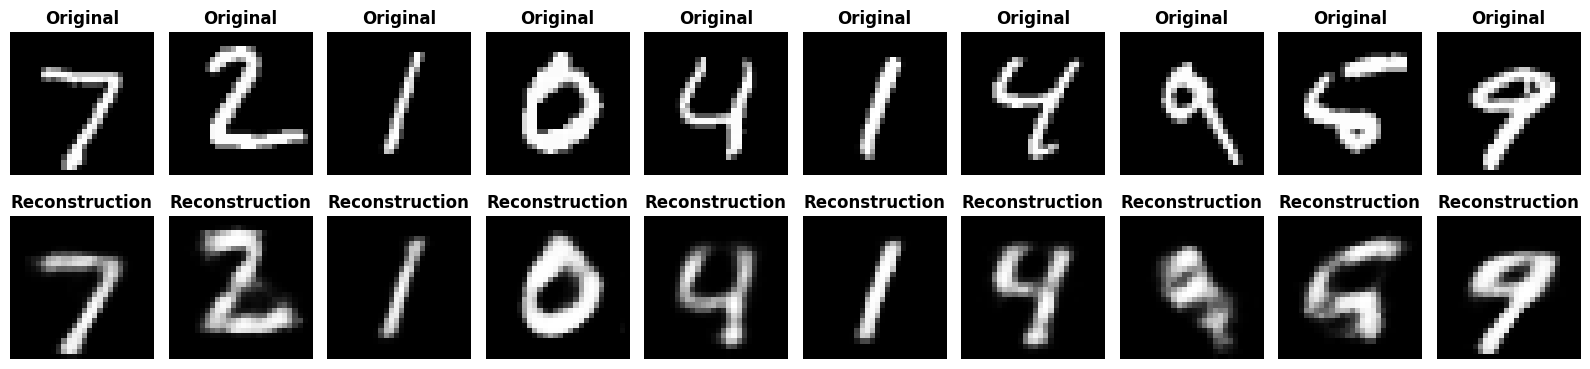

In [7]:
#Plot 1: original vs reconstructured imgs
fc_recon_flat = fc_autoencoder.predict(x_test.reshape(-1, 784), batch_size=BATCH_SIZE, verbose=0)
fc_recon = fc_recon_flat.reshape(-1, 28, 28, 1)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original", fontweight="bold")
    axes[0, i].axis("off")
    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Reconstruction", fontweight="bold")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot1_fc_original_vs_reconstruction.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


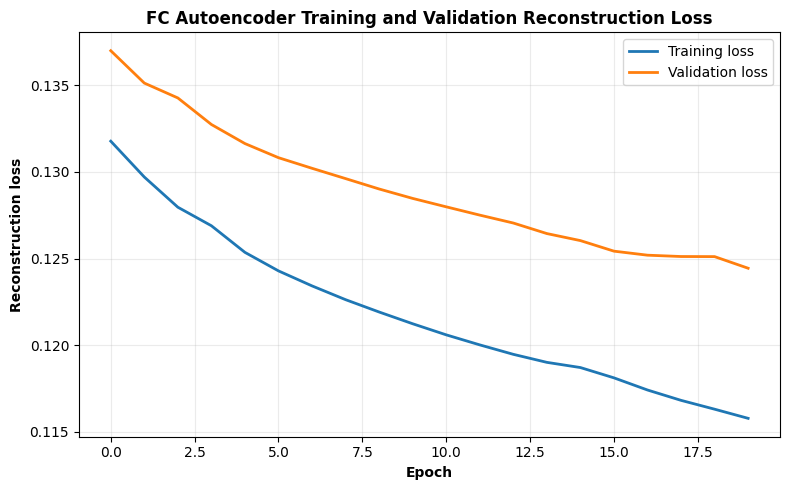

In [9]:
#Training and validation reconstruction loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_fc.history["loss"], linewidth=2, label="Training loss")
ax.plot(history_fc.history["val_loss"], linewidth=2, label="Validation loss")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Reconstruction loss", fontweight="bold")
ax.set_title("FC Autoencoder Training and Validation Reconstruction Loss")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot2_fc_training_validation_loss.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [10]:
#Reconstruction metrics: MSE, MAE, SSIM
def reconstruction_metrics(original, reconstructed):
    original = np.asarray(original)
    reconstructed = np.asarray(reconstructed)

    mse = np.mean((original - reconstructed) ** 2)
    mae = np.mean(np.abs(original - reconstructed))

    ssim_values = [
        structural_similarity(
            original[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(original))
    ]
    return mse, mae, float(np.mean(ssim_values)), np.array(ssim_values)

fc_mse, fc_mae, fc_ssim, fc_ssim_values = reconstruction_metrics(x_test, fc_recon)

fc_metrics = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [fc_mse, fc_mae, fc_ssim]
})
fc_metrics


,Metric,Value
0,Test MSE,0.019823
1,Test MAE,0.053790
2,Mean SSIM,0.765471


In [11]:
# Convolutional Autoencoder
cae_input = keras.Input(shape=(28, 28, 1), name="cae_input")
x = layers.Conv2D(32, 3, activation="relu", padding="same")(cae_input)
x = layers.MaxPooling2D(2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)
cae_latent = layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_feature_map")(x)
x = layers.UpSampling2D(2)(cae_latent)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)
cae_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

cae = keras.Model(cae_input, cae_output, name="convolutional_autoencoder")
cae_encoder = keras.Model(cae_input, cae_latent, name="cae_encoder")

cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

cae.summary()


Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cae_start = time.time()

history_cae = cae.fit(
    x_train,
    x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

cae_time = time.time() - cae_start
cae_recon = cae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
cae_mse, cae_mae, cae_ssim, cae_ssim_values = reconstruction_metrics(x_test, cae_recon)

cae_metrics = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [cae_mse, cae_mae, cae_ssim]
})
cae_metrics


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 0.2312 - val_loss: 0.1063
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0942 - val_loss: 0.0899
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0839 - val_loss: 0.0835
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0796 - val_loss: 0.0796
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0772 - val_loss: 0.0777
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0756 - val_loss: 0.0764
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0745 - val_loss: 0.0756
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0736 - val_loss: 0.0748
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0728 - val_loss: 0.0742
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0722 - val_loss: 0.0733
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0716 - val_loss: 0.0730
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0712 - val_l

,Metric,Value
0,Test MSE,0.002706
1,Test MAE,0.015344
2,Mean SSIM,0.972631


In [13]:
#Comparison between fully connected and convolutional AEs
model_comparison = pd.DataFrame({
    "Model": ["Fully Connected AE", "Convolutional AE"],
    "MSE": [fc_mse, cae_mse],
    "MAE": [fc_mae, cae_mae],
    "SSIM": [fc_ssim, cae_ssim],
    "Parameters": [fc_autoencoder.count_params(), cae.count_params()]
})
model_comparison


,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.019823,0.053790,0.765471,211040
1,Convolutional AE,0.002706,0.015344,0.972631,74497


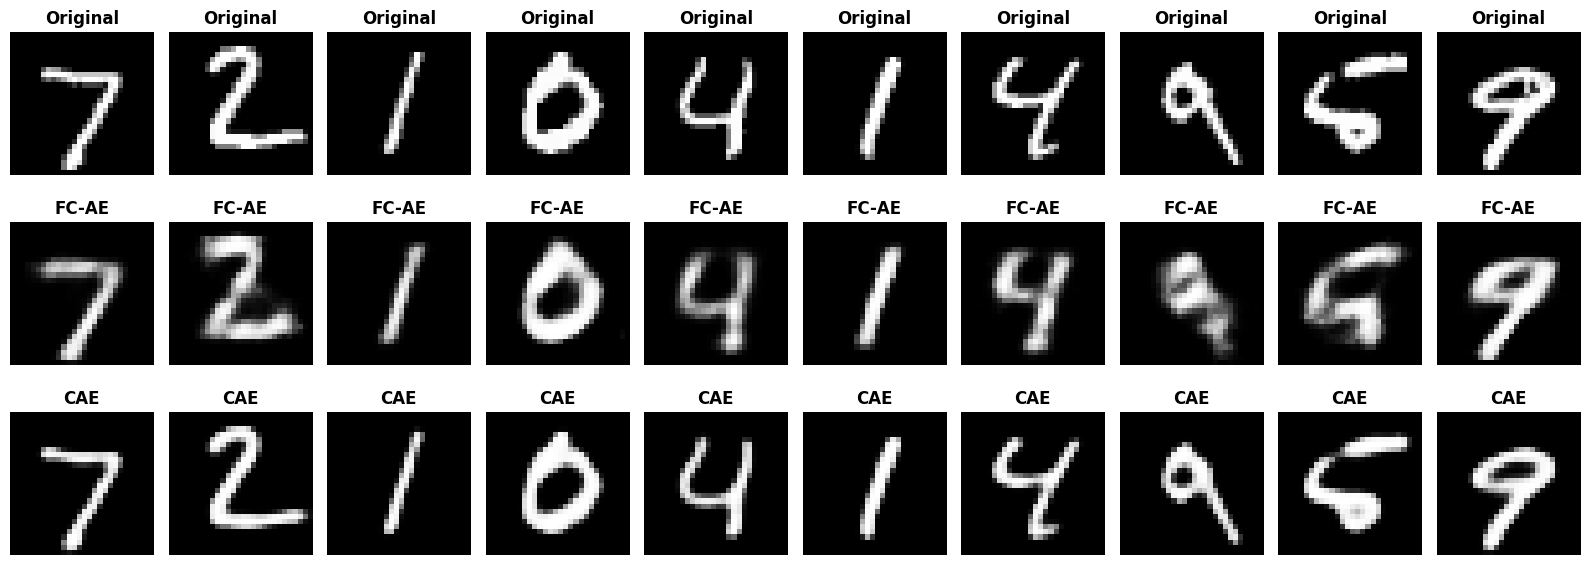

In [14]:
#Reconstruction comparison between FC-AE and CAE
fig, axes = plt.subplots(3, 10, figsize=(16, 6))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original", fontweight="bold")
    axes[0, i].axis("off")

    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].set_title("FC-AE", fontweight="bold")
    axes[1, i].axis("off")

    axes[2, i].imshow(cae_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("CAE", fontweight="bold")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot3_fc_vs_cae_reconstruction.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


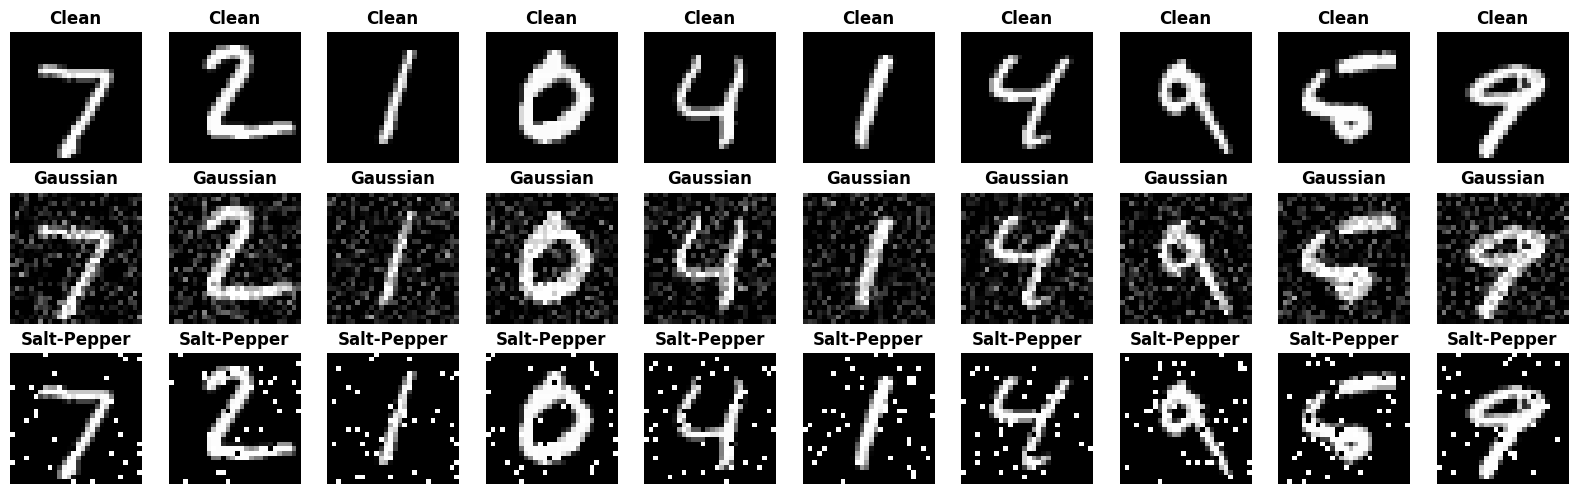

In [15]:
#Adding image noise
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, probability):
    noisy = images.copy()
    random_values = np.random.rand(*images.shape)

    noisy[random_values < probability / 2] = 0.0
    noisy[(random_values >= probability / 2) & (random_values < probability)] = 1.0

    return noisy.astype("float32")

# Visual check of both required corruption types.
sample_clean = x_test[:10]
sample_gaussian = add_gaussian_noise(sample_clean, 0.2)
sample_sp = add_salt_pepper_noise(sample_clean, 0.10)

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i in range(10):
    axes[0, i].imshow(sample_clean[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean", fontweight="bold")
    axes[0, i].axis("off")

    axes[1, i].imshow(sample_gaussian[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Gaussian", fontweight="bold")
    axes[1, i].axis("off")

    axes[2, i].imshow(sample_sp[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Salt-Pepper", fontweight="bold")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/denoising_noise_types.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [16]:
#Denoising CAE
def build_denoising_cae():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = keras.Model(inputs, outputs, name="denoising_cae")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model

# Main denoising model: Gaussian corruption, sigma=0.2.
dae_train_noisy = add_gaussian_noise(x_train, 0.2)

dae = build_denoising_cae()
dae_start = time.time()

history_dae = dae.fit(
    dae_train_noisy,
    x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

dae_time = time.time() - dae_start


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.2969 - val_loss: 0.1348
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1124 - val_loss: 0.1029
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0949 - val_loss: 0.0938
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0889 - val_loss: 0.0902
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0859 - val_loss: 0.0873
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0839 - val_loss: 0.0854
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0823 - val_loss: 0.0838
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0811 - val_loss: 0.0831
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0801 - val_loss: 0.0824
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0792 - val_loss: 0.0812
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0785 - val_loss: 0.0804
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0779 - val_l

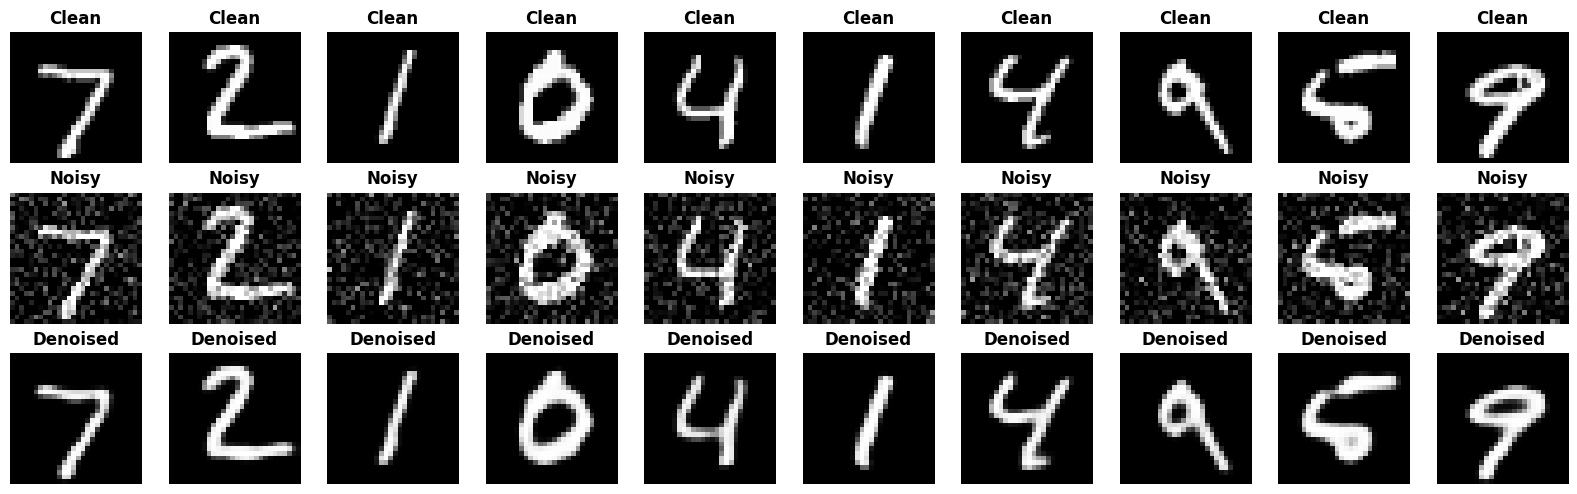

In [17]:
#clean vs noisy vs denoised
dae_test_noisy = add_gaussian_noise(x_test, 0.2)
dae_recon = dae.predict(dae_test_noisy, batch_size=BATCH_SIZE, verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean", fontweight="bold")
    axes[0, i].axis("off")

    axes[1, i].imshow(dae_test_noisy[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy", fontweight="bold")
    axes[1, i].axis("off")

    axes[2, i].imshow(dae_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Denoised", fontweight="bold")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot4_clean_noisy_denoised.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [18]:
#comparison between noise level and reconstruction quality
gaussian_results = []

for sigma in [0.1, 0.2, 0.3]:
    noisy = add_gaussian_noise(x_test, sigma)
    reconstructed = dae.predict(noisy, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim, _ = reconstruction_metrics(x_test, reconstructed)

    gaussian_results.append({
        "Noise Level": sigma,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim
    })

gaussian_results = pd.DataFrame(gaussian_results)
gaussian_results

,Noise Level,MSE,MAE,SSIM
0,0.1,0.003753,0.018029,0.958518
1,0.2,0.004687,0.021415,0.943362
2,0.3,0.007183,0.030019,0.862765


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


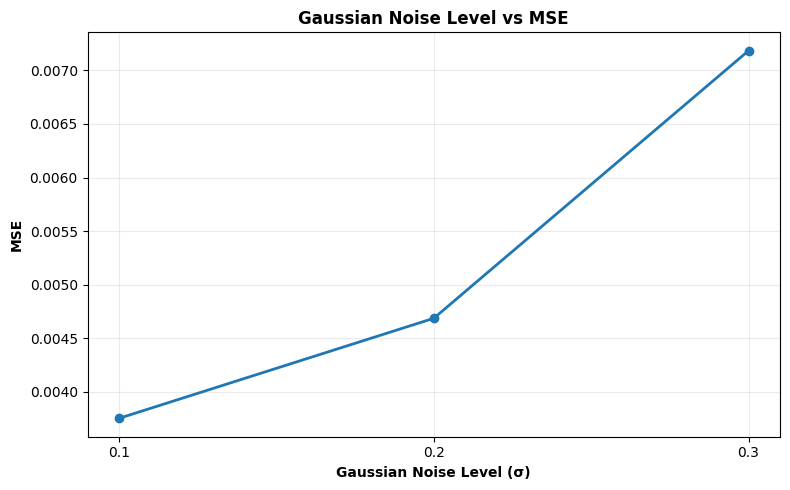

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


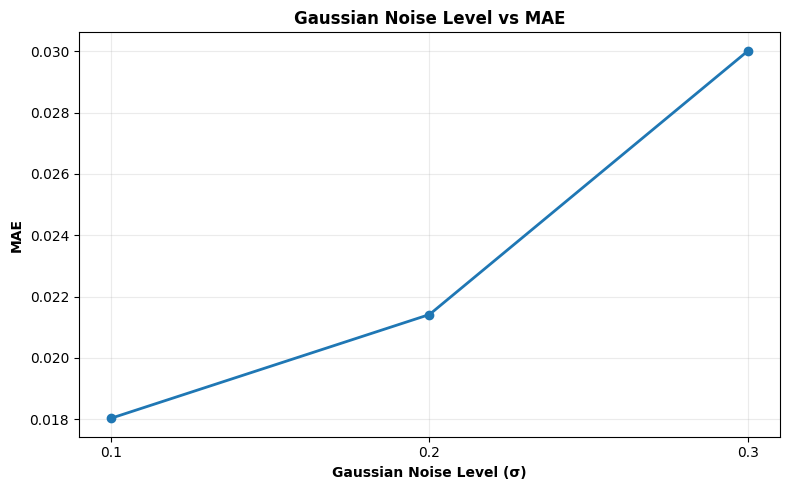

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


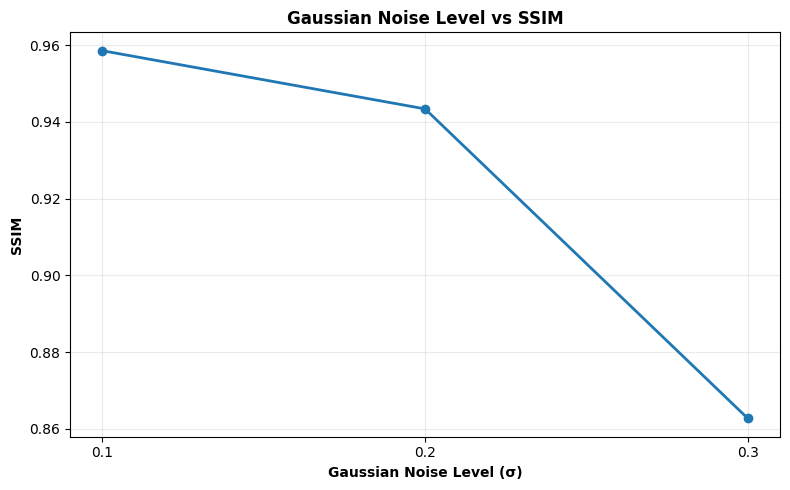

In [19]:
metrics_to_plot = ["MSE", "MAE", "SSIM"]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(gaussian_results["Noise Level"], gaussian_results[metric], marker="o", linewidth=2)
    ax.set_xlabel("Gaussian Noise Level (σ)", fontweight="bold")
    ax.set_ylabel(metric, fontweight="bold")
    ax.set_title(f"Gaussian Noise Level vs {metric}")
    ax.set_xticks([0.1, 0.2, 0.3])
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/plot5_noise_vs_{metric.lower()}.eps", format="eps", dpi=600, bbox_inches="tight")
    plt.show()


In [20]:
#VAE Implementation
class VAE(keras.Model):
    def __init__(self, latent_dim=2, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.kl_weight = kl_weight

        self.encoder_conv = keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, 3, strides=2, padding="same", activation="relu"),
            layers.Conv2D(64, 3, strides=2, padding="same", activation="relu"),
            layers.Flatten(),
            layers.Dense(128, activation="relu")
        ])

        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")

        self.decoder = keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(7 * 7 * 64, activation="relu"),
            layers.Reshape((7, 7, 64)),
            layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
            layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu"),
            layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")
        ])

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def encode(self, x, training=False):
        h = self.encoder_conv(x, training=training)
        z_mean = self.z_mean_layer(h)
        z_log_var = self.z_log_var_layer(h)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z_mean, z_log_var, z

    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encode(inputs, training=training)
        return self.decoder(z, training=training)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encode(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + self.kl_weight * kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encode(data, training=False)
        reconstruction = self.decoder(z, training=False)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

vae = VAE(latent_dim=2, kl_weight=1.0, name="vae_latent_2")
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae.summary()


Model: "vae_latent_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128)            │       420,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_mean (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_log_var (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,441 (1.85 MB)

 Trainable params: 485,441 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
vae_start = time.time()

history_vae = vae.fit(
    x_train,
    validation_data=(x_test,),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

vae_time = time.time() - vae_start


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - kl_loss: 2.9633 - reconstruction_loss: 291.1467 - total_loss: 294.1100 - val_kl_loss: 2.7044 - val_reconstruction_loss: 199.4945 - val_total_loss: 202.1989
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.2615 - reconstruction_loss: 198.1238 - total_loss: 201.3853 - val_kl_loss: 3.2488 - val_reconstruction_loss: 186.3529 - val_total_loss: 189.6017
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.2626 - reconstruction_loss: 189.0194 - total_loss: 192.2819 - val_kl_loss: 4.3329 - val_reconstruction_loss: 175.2825 - val_total_loss: 179.6154
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 4.2406 - reconstruction_loss: 177.5010 - total_loss: 181.7416 - val_kl_loss: 4.6063 - val_reconstruction_loss: 169.3123 - val_total_loss: 173.9186
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 4.4099 - reconstruction_loss: 172.7504 - total_loss: 177.1603 - val_kl_loss: 4.4212 - val_reconstruction_

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


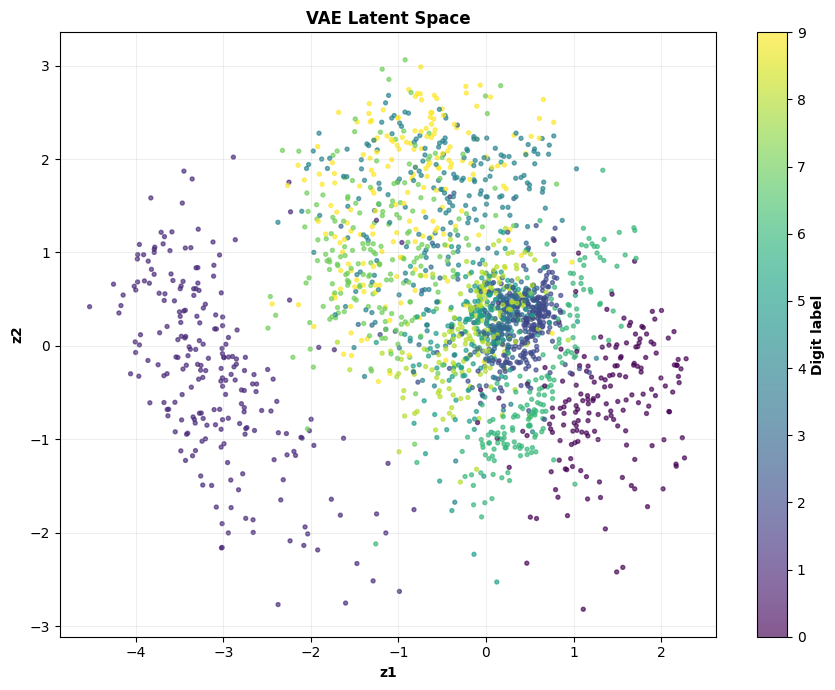

In [22]:
#VAE latent space
z_mean_test, z_log_var_test, z_test = vae.encode(x_test, training=False)

z_mean_test = z_mean_test.numpy()
z_log_var_test = z_log_var_test.numpy()

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    s=8,
    alpha=0.65
)
ax.set_xlabel("z1", fontweight="bold")
ax.set_ylabel("z2", fontweight="bold")
ax.set_title("VAE Latent Space")
ax.grid(alpha=0.2)
plt.colorbar(scatter, ax=ax, label="Digit label")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot6_vae_latent_space.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


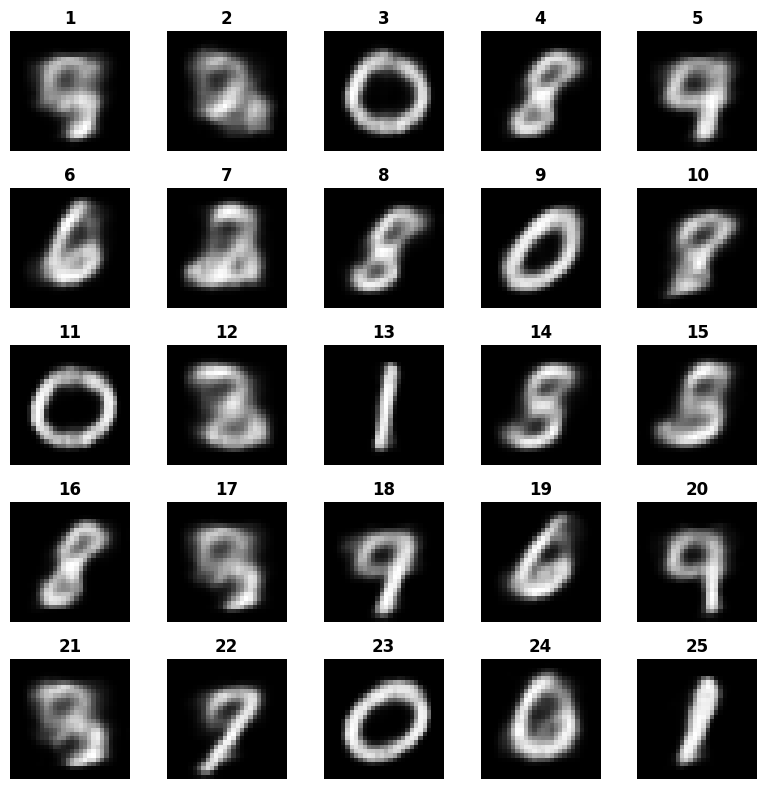

In [23]:
#generate new images with VAE
random_latents = np.random.normal(size=(25, 2)).astype("float32")
generated_images = vae.decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(), cmap="gray")
    ax.set_title(f"{i+1}", fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot7_vae_generated_images.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


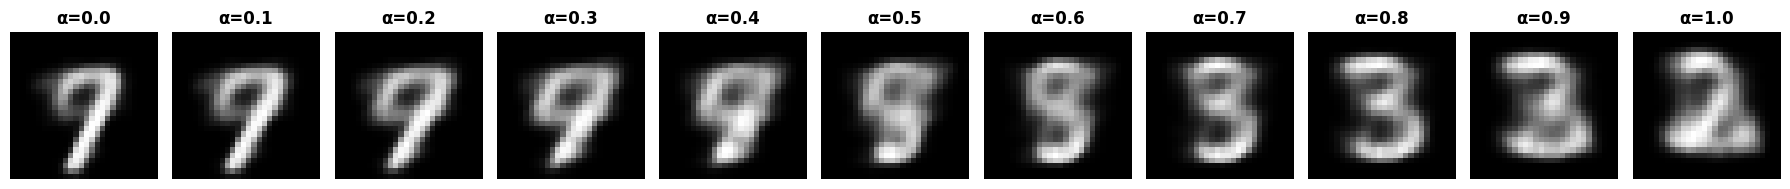

In [24]:
#latent space interpolation
z_a = z_mean_test[0]
z_b = z_mean_test[1]

alphas = np.linspace(0.0, 1.0, 11)
interpolated_latents = np.array([(1 - alpha) * z_a + alpha * z_b for alpha in alphas], dtype="float32")
interpolated_images = vae.decoder.predict(interpolated_latents, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(interpolated_images[i].squeeze(), cmap="gray")
    ax.set_title(f"α={alphas[i]:.1f}", fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot8_vae_latent_interpolation.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [25]:
#reconstruction comparison across all models
dae_mse, dae_mae, dae_ssim, dae_ssim_values = reconstruction_metrics(x_test, dae_recon)

# VAE deterministic reconstruction using z_mean, so that the test reconstruction
# metrics are stable and directly comparable.
vae_recon = vae.decoder.predict(z_mean_test.astype("float32"), batch_size=BATCH_SIZE, verbose=0)
vae_mse, vae_mae, vae_ssim, vae_ssim_values = reconstruction_metrics(x_test, vae_recon)

reconstruction_comparison = pd.DataFrame({
    "Model": ["Fully Connected AE", "Convolutional AE", "Denoising CAE"],
    "MSE": [fc_mse, cae_mse, dae_mse],
    "MAE": [fc_mae, cae_mae, dae_mae],
    "SSIM": [fc_ssim, cae_ssim, dae_ssim],
    "Parameters": [fc_autoencoder.count_params(), cae.count_params(), dae.count_params()]
})

reconstruction_comparison


,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.019823,0.053790,0.765471,211040
1,Convolutional AE,0.002706,0.015344,0.972631,74497
2,Denoising CAE,0.004688,0.021415,0.943420,74497


In [26]:
vae_reconstruction_loss = float(np.mean(history_vae.history["reconstruction_loss"]))
vae_kl_loss = float(np.mean(history_vae.history["kl_loss"]))
vae_total_loss = float(np.mean(history_vae.history["total_loss"]))

vae_metrics = pd.DataFrame({
    "VAE Metric": [
        "Reconstruction Loss",
        "KL Loss",
        "Total Loss",
        "Test MSE",
        "Test MAE",
        "Mean SSIM"
    ],
    "Value": [
        vae_reconstruction_loss,
        vae_kl_loss,
        vae_total_loss,
        vae_mse,
        vae_mae,
        vae_ssim
    ]
})

vae_metrics


,VAE Metric,Value
0,Reconstruction Loss,168.600256
1,KL Loss,4.806532
2,Total Loss,173.406800
3,Test MSE,0.043513
4,Test MAE,0.102146
5,Mean SSIM,0.493061


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


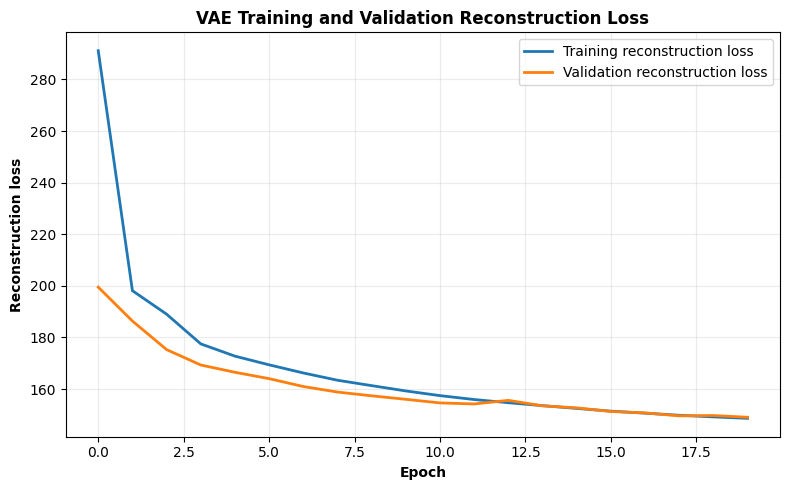

In [27]:
# Keras validation history contains the validation metric names.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_vae.history["reconstruction_loss"], linewidth=2, label="Training reconstruction loss")
ax.plot(history_vae.history["val_reconstruction_loss"], linewidth=2, label="Validation reconstruction loss")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Reconstruction loss", fontweight="bold")
ax.set_title("VAE Training and Validation Reconstruction Loss")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot9_vae_training_validation_reconstruction_loss.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


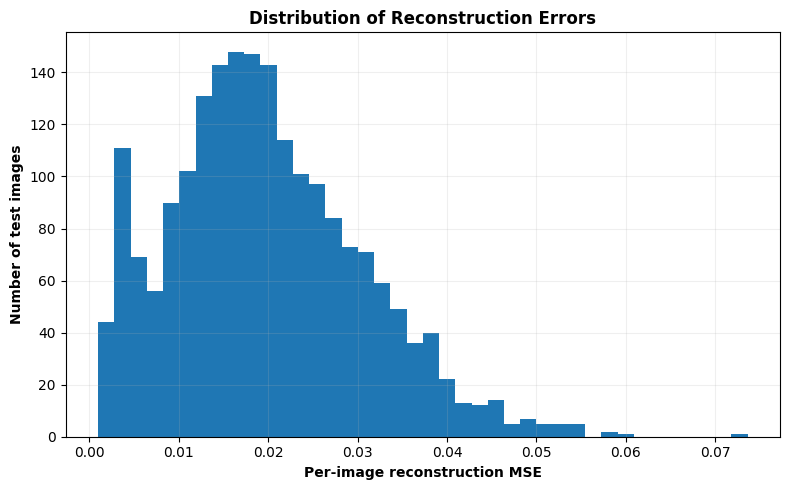

In [28]:
#reconstruction error distribution
per_image_error = np.mean(
    (x_test.reshape(len(x_test), -1) - fc_recon.reshape(len(fc_recon), -1)) ** 2,
    axis=1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(per_image_error, bins=40)
ax.set_xlabel("Per-image reconstruction MSE", fontweight="bold")
ax.set_ylabel("Number of test images", fontweight="bold")
ax.set_title("Distribution of Reconstruction Errors")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot10_reconstruction_error_distribution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


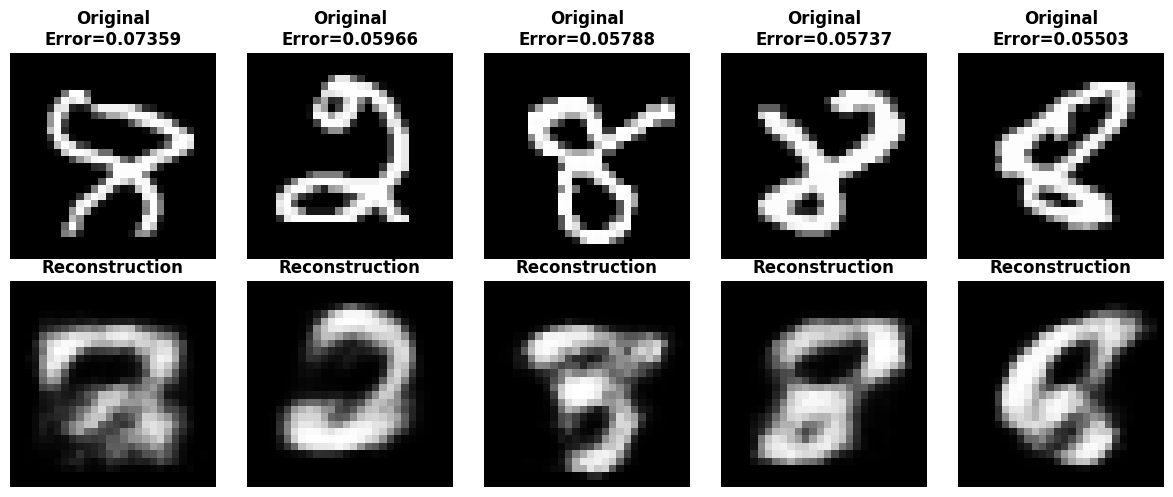

Top five high-error indices: [1782  744 1170 1859 1325]
Corresponding labels: [8 2 8 8 8]
Corresponding errors: [0.07358596 0.05965557 0.05788315 0.0573739  0.05503071]


In [29]:
#high error image analysis
top5_indices = np.argsort(per_image_error)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col, idx in enumerate(top5_indices):
    axes[0, col].imshow(x_test[idx].squeeze(), cmap="gray")
    axes[0, col].set_title(f"Original\nError={per_image_error[idx]:.5f}", fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(fc_recon[idx].squeeze(), cmap="gray")
    axes[1, col].set_title("Reconstruction", fontweight="bold")
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot11_top5_high_error_images.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

print("Top five high-error indices:", top5_indices)
print("Corresponding labels:", y_test[top5_indices])
print("Corresponding errors:", per_image_error[top5_indices])


In [31]:
#all results
consolidated_results = pd.DataFrame({
    "Model": ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"],
    "MSE": [fc_mse, cae_mse, dae_mse, vae_mse],
    "MAE": [fc_mae, cae_mae, dae_mae, vae_mae],
    "SSIM": [fc_ssim, cae_ssim, dae_ssim, vae_ssim],
    "Parameters": [
        fc_autoencoder.count_params(),
        cae.count_params(),
        dae.count_params(),
        sum(np.prod(v.shape) for v in vae.trainable_variables)
    ],
    "Time (s)": [fc_time, cae_time, dae_time, vae_time]
})

consolidated_results

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,FC Autoencoder,0.019823,0.053790,0.765471,211040,5.955454
1,Conv. Autoencoder,0.002706,0.015344,0.972631,74497,18.928944
2,Denoising CAE,0.004688,0.021415,0.943420,74497,16.869996
3,VAE,0.043513,0.102146,0.493061,485957,22.860430


In [32]:
#Additional latent-dimension study
def build_fc_autoencoder(latent_dim):
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=f"fc_ae_latent_{latent_dim}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model

latent_dimension_results = []

for latent_dim in [2, 8, 16, 32]:
    model = build_fc_autoencoder(latent_dim)

    model.fit(
        x_train.reshape(-1, 784),
        x_train.reshape(-1, 784),
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    reconstructed = model.predict(x_test.reshape(-1, 784), batch_size=BATCH_SIZE, verbose=0)
    reconstructed = reconstructed.reshape(-1, 28, 28, 1)

    mse, mae, ssim, _ = reconstruction_metrics(x_test, reconstructed)

    latent_dimension_results.append({
        "Latent Dimension": latent_dim,
        "MSE": mse,
        "SSIM": ssim,
        "Parameters": model.count_params()
    })

latent_dimension_results = pd.DataFrame(latent_dimension_results)
latent_dimension_results


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.3633 - val_loss: 0.2695
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2636 - val_loss: 0.2629
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2591 - val_loss: 0.2604
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2561 - val_loss: 0.2583
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2535 - val_loss: 0.2558
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2496 - val_loss: 0.2452
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2347 - val_loss: 0.2350
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2269 - val_loss: 0.2264
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2213 - val_loss: 0.2222
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2181 - val_loss: 0.2193
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2154 - val_loss: 0.2173
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2134 - val_l

,Latent Dimension,MSE,SSIM,Parameters
0,2,0.048178,0.423845,210130
1,8,0.031188,0.635880,210520
2,16,0.023132,0.724894,211040
3,32,0.022016,0.736143,212080


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


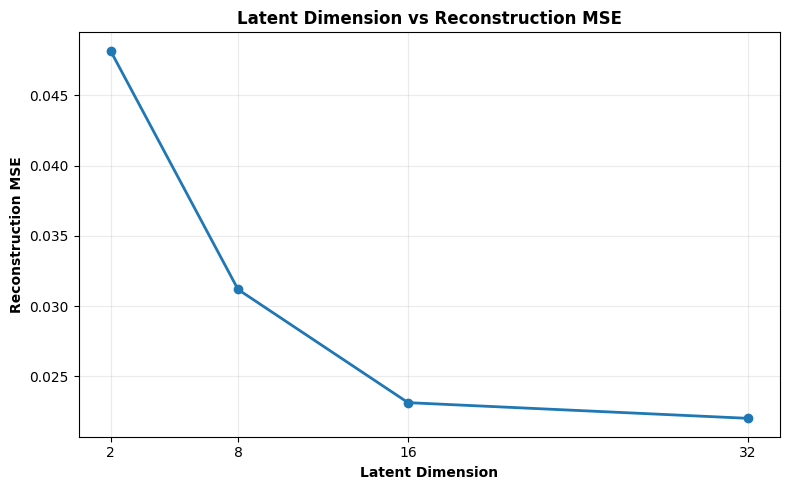

In [33]:
#Latent dimension vs reconstruction MSE
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    latent_dimension_results["Latent Dimension"],
    latent_dimension_results["MSE"],
    marker="o",
    linewidth=2
)
ax.set_xlabel("Latent Dimension", fontweight="bold")
ax.set_ylabel("Reconstruction MSE", fontweight="bold")
ax.set_title("Latent Dimension vs Reconstruction MSE")
ax.set_xticks([2, 8, 16, 32])
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/plot12_latent_dimension_vs_mse.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [34]:
#Additional exercise 1: CAE latent dimensions 4, 8, 16, 32
def build_cae_with_latent_channels(latent_dim):
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    latent = layers.Conv2D(latent_dim, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(latent)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = keras.Model(inputs, outputs, name=f"cae_latent_{latent_dim}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model

additional_cae_results = []

for latent_dim in [4, 8, 16, 32]:
    model = build_cae_with_latent_channels(latent_dim)
    model.fit(
        x_train,
        x_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    reconstructed = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim, _ = reconstruction_metrics(x_test, reconstructed)

    additional_cae_results.append({
        "CAE Latent Dimension": latent_dim,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim,
        "Parameters": model.count_params()
    })

additional_cae_results = pd.DataFrame(additional_cae_results)
additional_cae_results


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.4300 - val_loss: 0.1945
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1478 - val_loss: 0.1222
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1102 - val_loss: 0.1040
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0952 - val_loss: 0.0933
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0881 - val_loss: 0.0882
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0844 - val_loss: 0.0852
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0819 - val_loss: 0.0829
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0802 - val_loss: 0.0813
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0788 - val_loss: 0.0804
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0778 - val_loss: 0.0794
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0770 - val_loss: 0.0786
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0764 - val_l

,CAE Latent Dimension,MSE,MAE,SSIM,Parameters
0,4,0.004145,0.019508,0.956986,22597
1,8,0.003690,0.018179,0.963038,26057
2,16,0.003225,0.017023,0.966998,32977
3,32,0.003029,0.016241,0.969034,46817


In [35]:
#Additional exercise 1: Guassian noise vs salt-and-pepper noise
gaussian_train = add_gaussian_noise(x_train, 0.2)
sp_train = add_salt_pepper_noise(x_train, 0.10)

dae_gaussian = build_denoising_cae()
dae_salt_pepper = build_denoising_cae()

dae_gaussian.fit(
    gaussian_train, x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

dae_salt_pepper.fit(
    sp_train, x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

gaussian_test = add_gaussian_noise(x_test, 0.2)
sp_test = add_salt_pepper_noise(x_test, 0.10)

gaussian_denoised = dae_gaussian.predict(gaussian_test, batch_size=BATCH_SIZE, verbose=0)
sp_denoised = dae_salt_pepper.predict(sp_test, batch_size=BATCH_SIZE, verbose=0)

g_mse, g_mae, g_ssim, _ = reconstruction_metrics(x_test, gaussian_denoised)
sp_mse, sp_mae, sp_ssim, _ = reconstruction_metrics(x_test, sp_denoised)

noise_type_results = pd.DataFrame({
    "Noise Type": ["Gaussian σ=0.2", "Salt-and-Pepper p=0.10"],
    "MSE": [g_mse, sp_mse],
    "MAE": [g_mae, sp_mae],
    "SSIM": [g_ssim, sp_ssim]
})

noise_type_results


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.2813 - val_loss: 0.1293
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1092 - val_loss: 0.1001
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0934 - val_loss: 0.0925
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0879 - val_loss: 0.0884
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0849 - val_loss: 0.0859
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0828 - val_loss: 0.0838
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0814 - val_loss: 0.0825
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0801 - val_loss: 0.0813
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0795 - val_loss: 0.0806
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0786 - val_loss: 0.0800
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0782 - val_loss: 0.0794
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0776 - val_l

,Noise Type,MSE,MAE,SSIM
0,Gaussian σ=0.2,0.004603,0.021231,0.944978
1,Salt-and-Pepper p=0.10,0.005024,0.021548,0.943498


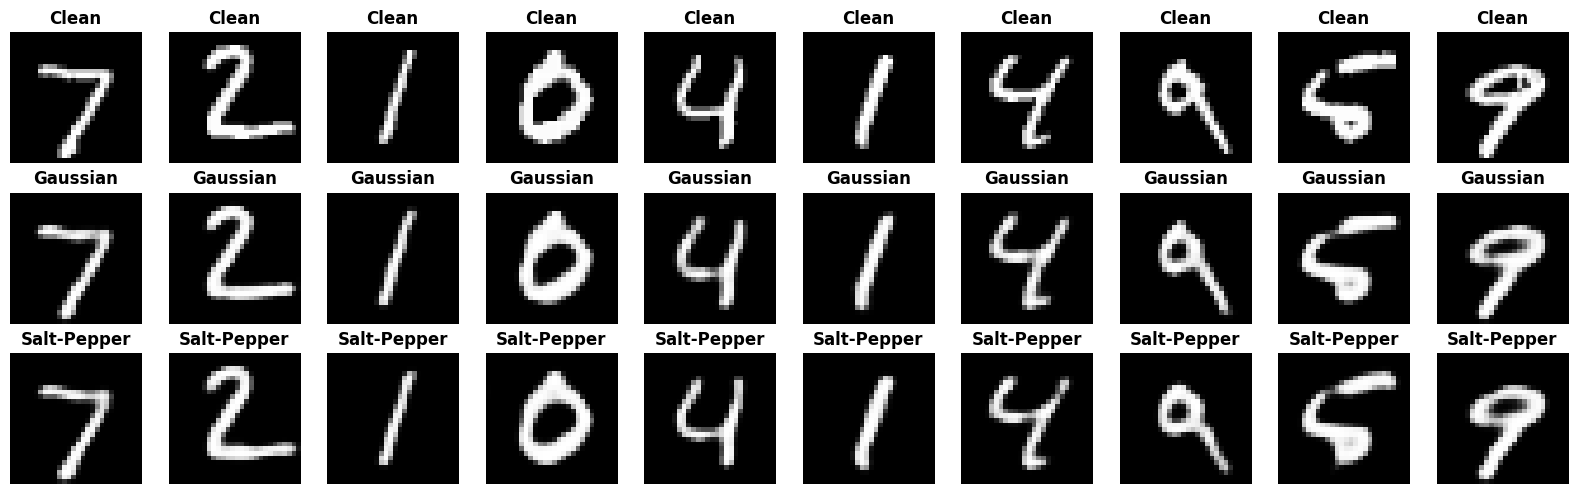

In [36]:
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean", fontweight="bold")
    axes[0, i].axis("off")

    axes[1, i].imshow(gaussian_denoised[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Gaussian", fontweight="bold")
    axes[1, i].axis("off")

    axes[2, i].imshow(sp_denoised[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Salt-Pepper", fontweight="bold")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/additional2_noise_type_comparison.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [37]:
#Additional exercise 1: Two noise levels and SSIM
noise_level_ssim = []

for sigma in [0.1, 0.3]:
    noisy_train = add_gaussian_noise(x_train, sigma)
    model = build_denoising_cae()

    model.fit(
        noisy_train, x_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    noisy_test = add_gaussian_noise(x_test, sigma)
    denoised = model.predict(noisy_test, batch_size=BATCH_SIZE, verbose=0)
    _, _, ssim, _ = reconstruction_metrics(x_test, denoised)

    noise_level_ssim.append({
        "Gaussian Noise σ": sigma,
        "SSIM": ssim
    })

noise_level_ssim = pd.DataFrame(noise_level_ssim)
noise_level_ssim


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.2480 - val_loss: 0.1207
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1023 - val_loss: 0.0945
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0887 - val_loss: 0.0874
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0836 - val_loss: 0.0838
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - val_loss: 0.0811
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0786 - val_loss: 0.0799
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0772 - val_loss: 0.0780
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0760 - val_loss: 0.0770
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0752 - val_loss: 0.0762
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0744 - val_loss: 0.0755
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0738 - val_loss: 0.0749
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0733 - val_l

,Gaussian Noise σ,SSIM
0,0.1,0.962639
1,0.3,0.917817


In [38]:
#Additional exercise 1: Transposed convolution decoder
def build_transposed_decoder_cae():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    latent = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(latent)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = keras.Model(inputs, outputs, name="transposed_decoder_cae")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model

transposed_cae = build_transposed_decoder_cae()

transposed_cae.fit(
    x_train,
    x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

transposed_recon = transposed_cae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
td_mse, td_mae, td_ssim, _ = reconstruction_metrics(x_test, transposed_recon)

decoder_comparison = pd.DataFrame({
    "Decoder": ["UpSampling2D", "Conv2DTranspose"],
    "MSE": [cae_mse, td_mse],
    "MAE": [cae_mae, td_mae],
    "SSIM": [cae_ssim, td_ssim]
})

decoder_comparison


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.3289 - val_loss: 0.1259
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0967 - val_loss: 0.0875
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0819 - val_loss: 0.0806
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0771 - val_loss: 0.0769
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0742 - val_loss: 0.0746
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0724 - val_loss: 0.0731
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0712 - val_loss: 0.0721
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0704 - val_loss: 0.0714
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0698 - val_loss: 0.0708
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0693 - val_loss: 0.0703
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0688 - val_loss: 0.0699
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0685 - va

,Decoder,MSE,MAE,SSIM
0,UpSampling2D,0.002706,0.015344,0.972631
1,Conv2DTranspose,0.002058,0.013220,0.979364


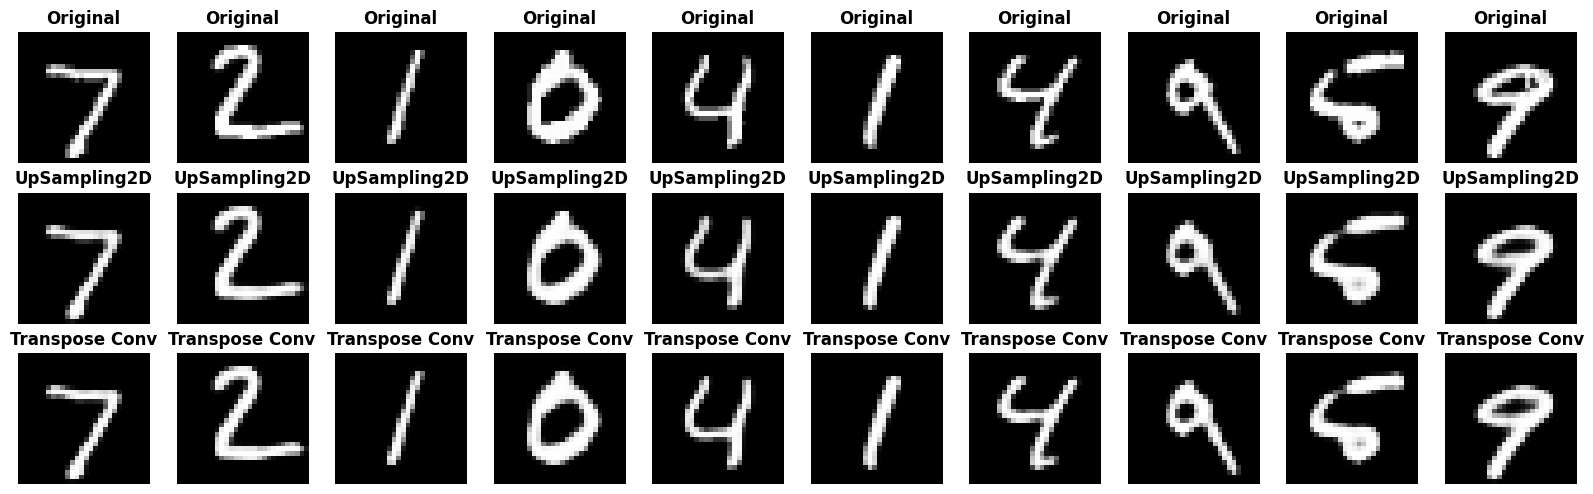

In [39]:
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original", fontweight="bold")
    axes[0, i].axis("off")

    axes[1, i].imshow(cae_recon[i].squeeze(), cmap="gray")
    axes[1, i].set_title("UpSampling2D", fontweight="bold")
    axes[1, i].axis("off")

    axes[2, i].imshow(transposed_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Transpose Conv", fontweight="bold")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/additional4_decoder_comparison.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


In [40]:
#Additional exercise 1: VAE latent dimensions 2 and 8
vae_latent_models = {}
vae_latent_results = []

for latent_dim in [2, 8]:
    model = VAE(latent_dim=latent_dim, kl_weight=1.0, name=f"vae_latent_{latent_dim}")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    model.fit(
        x_train,
        validation_data=(x_test,),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    z_mean, z_log_var, z = model.encode(x_test, training=False)
    z_mean_np = z_mean.numpy()
    reconstruction = model.decoder.predict(z_mean_np, batch_size=BATCH_SIZE, verbose=0)

    mse, mae, ssim, _ = reconstruction_metrics(x_test, reconstruction)

    vae_latent_models[latent_dim] = model
    vae_latent_results.append({
        "VAE Latent Dimension": latent_dim,
        "Test MSE": mse,
        "Test MAE": mae,
        "Mean SSIM": ssim
    })

vae_latent_results = pd.DataFrame(vae_latent_results)
vae_latent_results


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - kl_loss: 4.7427 - reconstruction_loss: 277.8998 - total_loss: 282.6425 - val_kl_loss: 3.5649 - val_reconstruction_loss: 191.6462 - val_total_loss: 195.2110
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.0234 - reconstruction_loss: 194.3621 - total_loss: 197.3855 - val_kl_loss: 2.8595 - val_reconstruction_loss: 184.8238 - val_total_loss: 187.6833
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.7320 - reconstruction_loss: 181.5943 - total_loss: 185.3263 - val_kl_loss: 4.0867 - val_reconstruction_loss: 170.5979 - val_total_loss: 174.6846
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.2894 - reconstruction_loss: 173.7004 - total_loss: 177.9898 - val_kl_loss: 4.2416 - val_reconstruction_loss: 166.4585 - val_total_loss: 170.7001
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.4229 - reconstruction_loss: 170.3316 - total_loss: 174.7546 - val_kl_loss: 4.7019 - val_reconstruction_l

,VAE Latent Dimension,Test MSE,Test MAE,Mean SSIM
0,2,0.043201,0.100995,0.495819
1,8,0.019945,0.053536,0.775770


In [41]:
#Additional exercise 1: Effect of increasing KL-Loss contribution
kl_weight_results = []

for kl_weight in [0.5, 1.0, 2.0]:
    model = VAE(latent_dim=2, kl_weight=kl_weight, name=f"vae_beta_{kl_weight}")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    model.fit(
        x_train,
        validation_data=(x_test,),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    z_mean, z_log_var, z = model.encode(x_test, training=False)
    reconstruction = model.decoder.predict(z_mean, batch_size=BATCH_SIZE, verbose=0)

    mse, mae, ssim, _ = reconstruction_metrics(x_test, reconstruction)

    kl_weight_results.append({
        "KL Weight": kl_weight,
        "Test MSE": mse,
        "Test MAE": mae,
        "Mean SSIM": ssim,
        "Final Reconstruction Loss": float(model.history.history["reconstruction_loss"][-1]),
        "Final KL Loss": float(model.history.history["kl_loss"][-1]),
        "Final Total Loss": float(model.history.history["total_loss"][-1])
    })

kl_weight_results = pd.DataFrame(kl_weight_results)
kl_weight_results


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - kl_loss: 5.1556 - reconstruction_loss: 280.9415 - total_loss: 283.5194 - val_kl_loss: 5.5135 - val_reconstruction_loss: 195.7706 - val_total_loss: 198.5274
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.5140 - reconstruction_loss: 196.8771 - total_loss: 199.1341 - val_kl_loss: 4.6269 - val_reconstruction_loss: 186.0477 - val_total_loss: 188.3611
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.7739 - reconstruction_loss: 186.9600 - total_loss: 189.3470 - val_kl_loss: 5.8509 - val_reconstruction_loss: 174.0767 - val_total_loss: 177.0022
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 5.7512 - reconstruction_loss: 175.9640 - total_loss: 178.8396 - val_kl_loss: 5.7955 - val_reconstruction_loss: 168.7489 - val_total_loss: 171.6466
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 5.6180 - reconstruction_loss: 172.7291 - total_loss: 175.5381 - val_kl_loss: 5.7098 - val_reconstruction_l

,KL Weight,Test MSE,Test MAE,Mean SSIM,Final Reconstruction Loss,Final KL Loss,Final Total Loss
0,0.5,0.043435,0.101362,0.491266,146.966202,6.977680,150.455048
1,1.0,0.043112,0.101105,0.493739,146.692734,5.849274,152.541992
2,2.0,0.043924,0.104521,0.475965,150.091370,4.746000,159.583359


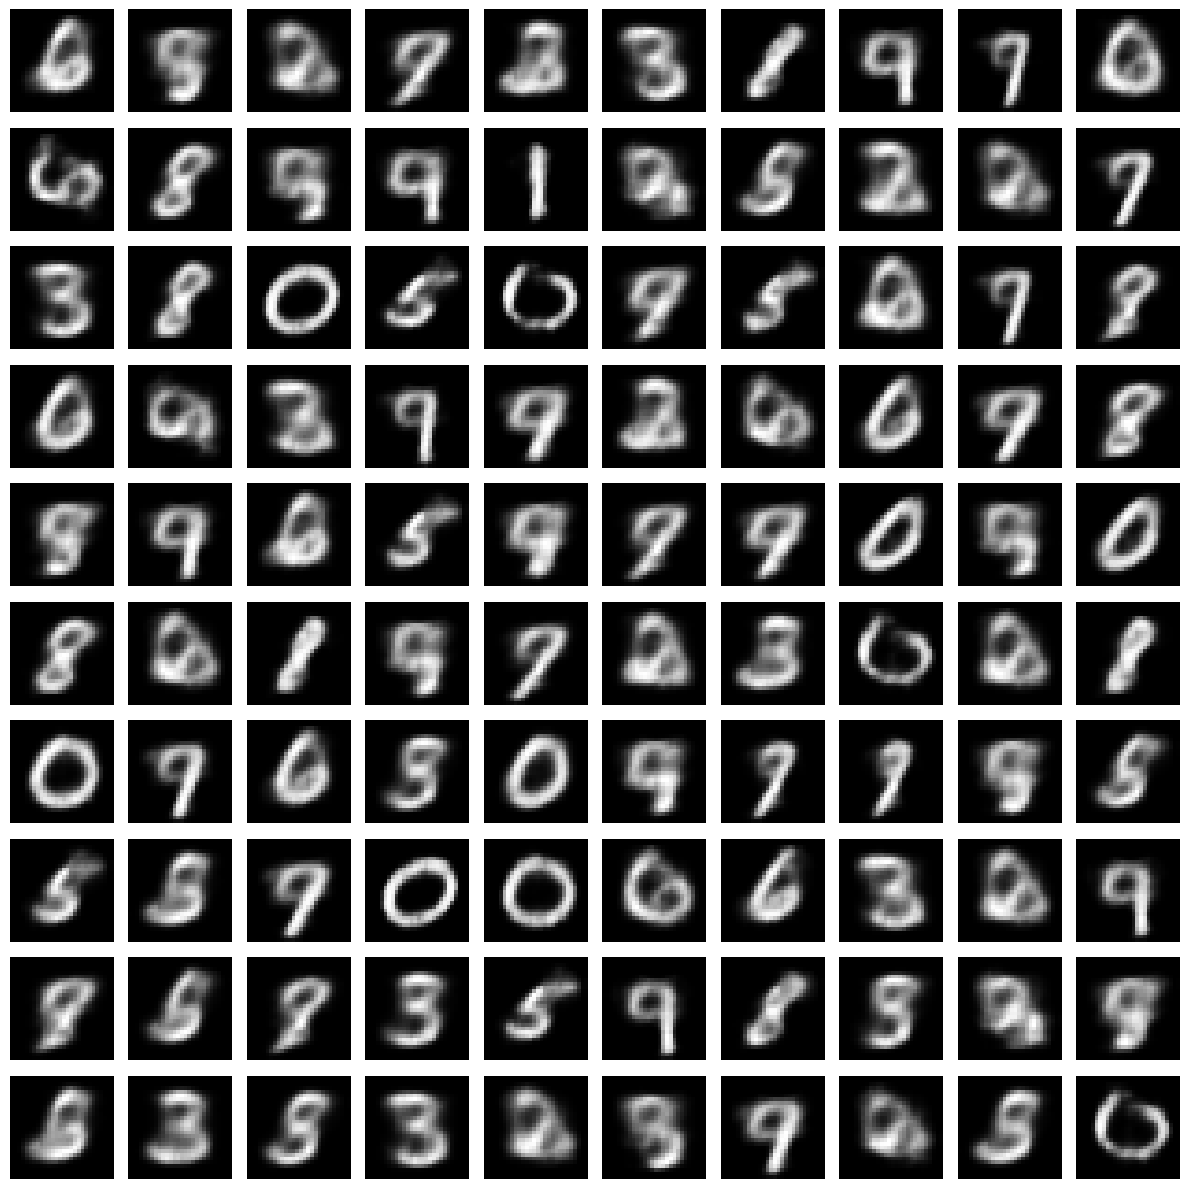

In [42]:
#Additional exercise 1: Larger VAE sample grid
large_latents = np.random.normal(size=(100, 2)).astype("float32")
large_generated = vae.decoder.predict(large_latents, batch_size=BATCH_SIZE, verbose=0)

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(large_generated[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/additional7_large_vae_generation_grid.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()


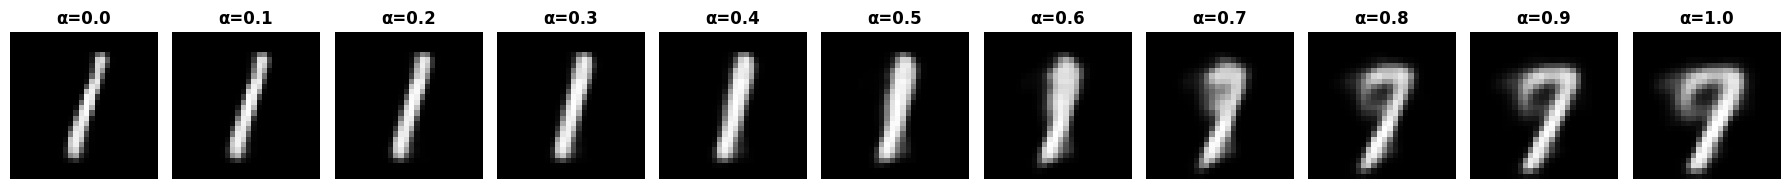

Interpolation endpoints: 1 to 7


In [44]:
#Additional exercise 1: select two digit regionbs and perform interpolation
idx_a_candidates = np.where(y_test == 1)[0]
idx_b_candidates = np.where(y_test == 7)[0]

idx_a = idx_a_candidates[0]
idx_b = idx_b_candidates[0]

z_a = z_mean_test[idx_a]
z_b = z_mean_test[idx_b]

region_alphas = np.linspace(0.0, 1.0, 11)
region_latents = np.array([
    (1 - alpha) * z_a + alpha * z_b
    for alpha in region_alphas
], dtype="float32")

region_images = vae.decoder.predict(region_latents, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(region_images[i].squeeze(), cmap="gray")
    ax.set_title(f"α={region_alphas[i]:.1f}", fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/additional8_digit_region_interpolation.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

print("Interpolation endpoints:", y_test[idx_a], "to", y_test[idx_b])


In [45]:
fc_metrics.to_csv(f"{FIG_DIR}/fc_metrics.csv", index=False)
cae_metrics.to_csv(f"{FIG_DIR}/cae_metrics.csv", index=False)
model_comparison.to_csv(f"{FIG_DIR}/fc_vs_cae.csv", index=False)
gaussian_results.to_csv(f"{FIG_DIR}/gaussian_noise_results.csv", index=False)
noise_type_results.to_csv(f"{FIG_DIR}/noise_type_comparison.csv", index=False)
reconstruction_comparison.to_csv(f"{FIG_DIR}/reconstruction_comparison.csv", index=False)
vae_metrics.to_csv(f"{FIG_DIR}/vae_metrics.csv", index=False)
consolidated_results.to_csv(f"{FIG_DIR}/consolidated_results.csv", index=False)
latent_dimension_results.to_csv(f"{FIG_DIR}/latent_dimension_results.csv", index=False)
additional_cae_results.to_csv(f"{FIG_DIR}/additional_cae_results.csv", index=False)
vae_latent_results.to_csv(f"{FIG_DIR}/vae_latent_results.csv", index=False)
kl_weight_results.to_csv(f"{FIG_DIR}/kl_weight_results.csv", index=False)

print(f"All figures and result tables are in: {FIG_DIR}/")


All figures and result tables are in: experiment7_figures/


In [46]:
import shutil

shutil.make_archive(
    "experiment7_results",
    "zip",
    "experiment7_figures"
)

print("ZIP created: experiment7_results.zip")

ZIP created: experiment7_results.zip
